# General variables and libraries
Run this cell first

In [1]:
import os
import cld4py
import numpy as np
import pandas as pd
from scipy import stats
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import colorcet as cc
import matplotlib.patches as mpatches
from patsy import ModelDesc
from statsmodels.formula.api import ols

%matplotlib inline

sns.set_style("ticks")
plt.rcParams['axes.linewidth'] = .5
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 500
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.facecolor'] = 'w'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

#VARIABLES
BIG = '/home/ty/Big_data/'
TABS = 'Data/Tables'
REPS = 'Data/Repseqs'
TAXA = 'Data/taxonomy.qza'
META = pd.read_csv('metadata.tsv', sep='\t', index_col=0)
TREE = 'Data/rooted_tree.qza'
CLASS = '/home/ty/Nextcloud/Projects/Classifiers/q2_24-10/Silva138_2'
TABLE = f'{TABS}/table.qza'
COREM = f'Results/Core-metrics'
BIGOUT = f'{BIG}/Burnings_big'
GEMELLI = f'Results/Gemelli'
REPSEQS = f'{REPS}/rep-seqs.qza'
SPECIES = [sp.replace('. ', '_') for sp in sorted(META.Species.unique())]

ALPHAS = {
    'faith_pd': 'Faith\'s\nPD',
    'shannon': 'Shannon\nentropy',
    'observed_features': 'Observed\nASVs',
}

runs = {
    'r1': f'{BIG}/LimBiom_run10/Demux/Dinara_Burnings',
    'r2': f'{BIG}/Burnings_2/Demux/Burnings-Dinara',
}

MDICT = {
    'BS': 's',
    'RhS': 'h',
    'Rt': 'P',
}

CDICT = {
     'Control': 'blue',
     'Burn': 'red',
}

SDICT = {
     'Annual': 10,
     'Perennial': 20,
}

!mkdir -p {TABS} {REPS} {GEMELLI} {BIGOUT} Results Figures

# Install dependencies

In [ ]:
!pip install colorcet
!pip install cld4py --upgrade
!pip install gemelli
!qiime dev refresh-cache

# Edit metadata file

In [ ]:
adds = {
    'Root': 'R',
    'Soil': 'S',
    'RhSph': 'RR',
}

META = pd.read_csv('metadata.tsv', sep='\t', index_col=0)
META.index = META.index +'-'+ META.sType.map(adds)
META.to_csv('metadata.tsv', sep='\t')
META

In [ ]:
META = pd.read_csv('metadata.tsv', sep='\t', index_col=0)
META['PID'] = META.index.str[:8]
META.to_csv('metadata.tsv', sep='\t')
META

# Import to Qiime2

In [ ]:
!mkdir -p Data/Demux

for run, demux in runs.items():

    #manifest
    samples = [s for s in os.listdir(demux) if '_R1_' in s]
    man = pd.DataFrame(data={
        'sample-id': [s.split('_')[0] for s in samples],
        'forward-absolute-filepath': [f'{demux}/{s}' for s in samples],
        'reverse-absolute-filepath': [f'{demux}/{s.replace("_R1_", "_R2_")}' for s in samples]
    })
    man.to_csv(f'Data/Demux/manifest_{run}.tsv', sep='\t', index=False)

    #import
    !qiime tools import \
        --type 'SampleData[PairedEndSequencesWithQuality]' \
        --input-path Data/Demux/manifest_{run}.tsv \
        --input-format 'PairedEndFastqManifestPhred33V2' \
        --output-path {BIGOUT}/{run}-demux.qza

    !qiime demux summarize \
        --i-data {BIGOUT}/{run}-demux.qza \
        --o-visualization Data/Demux/{run}-demux.qzv

# Cutadapt

In [ ]:
!mkdir -p Data/Cutadapt

for run in runs:
    fwd = 'AGRGTTHGATYMTGGCTCAG'
    rvs = 'TGCTGCCTCCCGTAGGAGT'
        
    !qiime cutadapt trim-paired \
        --i-demultiplexed-sequences {BIGOUT}/{run}-demux.qza \
        --o-trimmed-sequences {BIGOUT}/{run}-cutadapt.qza \
        --p-cores 4 \
        --p-front-f {fwd} \
        --p-front-r {rvs} \
        --p-match-adapter-wildcards \
        --p-discard-untrimmed \
        --p-match-read-wildcards

    !qiime demux summarize \
        --i-data {BIGOUT}/{run}-cutadapt.qza \
        --o-visualization Data/Cutadapt/{run}-cutadapt.qzv

# Dada2

In [ ]:
#dada2 for all Runs/regions
!mkdir -p Data/Dada2

for run in runs:

    !qiime dada2 denoise-paired \
        --p-n-threads 4 \
        --i-demultiplexed-seqs {BIGOUT}/{run}-cutadapt.qza \
        --p-trunc-len-f 200 \
        --p-trunc-len-r 190 \
        --o-table Data/Dada2/{run}-table.qza \
        --o-representative-sequences Data/Dada2/{run}-rep_seqs.qza \
        --o-denoising-stats Data/Dada2/{run}-stats.qza

    !qiime feature-table tabulate-seqs \
        --i-data Data/Dada2/{run}-rep_seqs.qza \
        --o-visualization Data/Dada2/{run}-rep_seqs.qzv

    !qiime metadata tabulate \
        --m-input-file Data/Dada2/{run}-stats.qza \
        --o-visualization Data/Dada2/{run}-stats.qzv

    !qiime feature-table summarize \
        --i-table Data/Dada2/{run}-table.qza \
        --o-visualization Data/Dada2/{run}-table.qzv

# Merge different runs

In [ ]:
# merge all regions from Dada2, but V13 from Dada2_V13 (concat)
!qiime feature-table merge \
    --i-tables Data/Dada2/*-table.qza \
    --o-merged-table {TABLE}

!qiime feature-table merge-seqs \
    --i-data Data/Dada2/*rep_seqs.qza \
    --o-merged-data {REPSEQS}

!qiime feature-table summarize \
    --i-table {TABLE} \
    --o-visualization {TABS}/table.qzv

# First filtering to remove rare features and extra samples

In [ ]:
#by frequency and prevalence
!qiime feature-table filter-features \
    --i-table {TABLE} \
    --p-min-frequency 10 \
    --p-min-samples 2 \
    --o-filtered-table {TABLE}

#summarize table
!qiime feature-table summarize \
    --i-table {TABLE} \
    --o-visualization {TABS}/frq10_smpl2_table.qzv

#filter rep-seqs
!qiime feature-table filter-seqs \
    --i-data {REPSEQS} \
    --i-table {TABLE} \
    --o-filtered-data {REPSEQS}

# Taxonomy assignment

In [ ]:
!qiime feature-classifier classify-hybrid-vsearch-sklearn \
    --i-query {REPSEQS} \
    --i-reference-reads {CLASS}/seqs-V12.qza \
    --i-reference-taxonomy {CLASS}/taxa-V12.qza \
    --i-classifier {CLASS}/classifier-V12.qza \
    --p-threads 4 \
    --p-no-prefilter \
    --o-classification {TAXA}

!qiime metadata tabulate \
    --m-input-file {TAXA} \
    --o-visualization Data/taxonomy.qzv

# Second filtering to remove unwanted features

In [ ]:
#remove organelles
!qiime taxa filter-table \
    --i-table {TABLE} \
    --i-taxonomy {TAXA} \
    --p-exclude mitochondria,chloroplast \
    --o-filtered-table {TABLE}

#samples by features depth
!qiime feature-table filter-samples \
    --i-table {TABLE} \
    --p-min-frequency 4000 \
    --o-filtered-table {TABLE}

#summarize
!qiime feature-table summarize \
    --i-table {TABLE} \
    --o-visualization {TABS}/second_filt_table.qzv

#repseqs by feature table
!qiime feature-table filter-seqs \
    --i-data {REPSEQS} \
    --i-table {TABLE} \
    --o-filtered-data {REPSEQS}

# Export to tsv

In [ ]:
!qiime tools export \
    --input-path {TABLE} \
    --output-path exported-table

!biom convert \
    -i exported-table/feature-table.biom \
    -o exported-table/ASV-table.tsv \
    --to-tsv

# Plant a tree

In [ ]:
!qiime phylogeny align-to-tree-mafft-fasttree \
    --i-sequences {REPSEQS} \
    --p-n-threads 4 \
    --o-alignment Data/aligned.qza \
    --o-masked-alignment Data/masked.qza \
    --o-tree Data/unrooted.qza \
    --o-rooted-tree {TREE}

!rm Data/aligned.qza Data/masked.qza Data/unrooted.qza

# Alpha rarefaction

In [ ]:
!qiime diversity alpha-rarefaction \
    --i-table {TABLE} \
    --i-phylogeny {TREE} \
    --p-max-depth 25000 \
    --m-metadata-file metadata.tsv \
    --o-visualization Results/alpha_rarefaction.qzv

# Core-metrics

In [ ]:
def find_depth(qzv):  
    a = !unzip $qzv
    out = a[1].split('/')[0].replace('  inflating: ', '')
    with open(f'{out}/data/sample-frequency-detail.html') as counts:
        freqs = counts.read().split('{"Frequency":{"')[-1].split('}}')[0]
        d = min([int(f.split('":')[-1]) for f in freqs.split('.0')[:-1]])
    !rm -rf $out
    return int(d)

depth = find_depth(f"{TABS}/second_filt_table.qzv")

!qiime diversity core-metrics-phylogenetic \
    --i-table {TABLE} \
    --i-phylogeny {TREE} \
    --p-sampling-depth {depth} \
    --m-metadata-file metadata.tsv \
    --p-n-jobs-or-threads 'auto' \
    --output-dir {COREM}

# Beta diversity

## Import libraries, declare common variables

In [2]:
adonis_out = 'Results/Adonis'

#function to modify adonis-strata output
def process_res(path, mode):
    resdf = pd.read_csv(path, sep='\t',)
    resdf[['Formula', 'Mode']] = [formula, mode]
    return resdf.loc[[i for i in resdf.index if i not in ['Residuals', 'Total']]]

#function to run adonis with strata
def run_adonis_strata(qza, meta, formula, strata=None, perms=999, t=4, pairwise=False):
    out = 'temp'
    
    !mkdir -p $out
    
    matrix = get_matrix(qza)
    subs = [m for m in matrix.columns if m in meta.index]
    matrix = matrix.loc[subs, subs]
    md = meta.loc[matrix.columns].copy()
    matrix.to_csv(f'{out}/matrix.tsv', sep='\t')        
    md.to_csv(f'{out}/md.tsv', sep='\t')
    adonisR = '/home/ty/Nextcloud/TY_scripts/run_adonis.R'
    columns = ['Df', 'SumsOfSqs', 'MeanSqs', 'F.Model', 'R2', 'Pr(>F)',\
               'Formula', 'Mode', 'Group1', 'Group2', 'p', 'q']
    summary = pd.DataFrame(columns = columns)
    com = f'{adonisR} {out}/matrix.tsv {out}/md.tsv {formula} {perms} {t} {strata} {out}/res.tsv'
                
    a = !$com

    resdf = process_res(f'{out}/res.tsv', 'General')
    summary = (summary.copy() if resdf.empty else resdf.copy() if summary.empty else pd.concat([summary, resdf]))
    
    if pairwise:
        for ind in pairwise:
            if resdf.loc[ind, 'Pr(>F)'] > .05: 
                continue
            subsum = pd.DataFrame(columns = columns)
            for pair in combinations(md[ind].unique(), 2):
                submd = md.loc[md[ind].isin(pair)]
                submx = matrix.loc[submd.index, submd.index].copy()
                submx.to_csv(f'{out}/mx-pairs.tsv', sep='\t')        
                submd.to_csv(f'{out}/md-pairs.tsv', sep='\t') 
                com = f'{adonisR} {out}/mx-pairs.tsv {out}/md-pairs.tsv {ind} {perms} {t} {strata} {out}/res-pairs.tsv'
                
                a = !$com
                
                subres = process_res(f'{out}/res-pairs.tsv', 'Pairwise')
                subres[['Group1', 'Group2']] = pair
                subsum = (subsum.copy() if subres.empty else subres.copy() if subsum.empty else pd.concat([subsum, subres]))
            subsum['p'] = subsum['Pr(>F)']
            subsum['Pr(>F)'] = resdf.loc[ind, 'Pr(>F)']
            subsum['q'] = multipletests(subsum['p'], method='fdr_bh')[1]
            subsum = subsum.loc[[ind], :].copy()
            summary = (summary.copy() if subsum.empty else subsum.copy() if summary.empty else pd.concat([summary, subsum]))

    !rm -r $out
    summary.index.name = 'Factor'
    return summary


# Unzipping qza pcoa
def parse_pcoa(qza): 
    a = !unzip $qza
    digest = a[1].split('/')[0].replace('  inflating: ', '')
    inf = digest + '/data/ordination.txt'
    lines = open(inf, 'r').readlines()
    Eigvals = [float(i) for i in lines[1].rstrip().split('\t')]
    Proportion = [float(i) for i in lines[4].rstrip().split('\t')]
    pca_skipr = len(open(inf,'r').read().split('Site')[0].splitlines()) + 1
    pcoa = pd.read_csv(inf, index_col=0, skiprows=pca_skipr, skipfooter=4,\
                       header=None, sep='\t', engine='python')
    !rm -r $digest
    return  pcoa, Proportion


#function to unzip matrix
def get_matrix(qza):
    a = !unzip $qza
    out = a[1].split('/')[0].replace('  inflating: ', '')
    inf = out + '/data/distance-matrix.tsv'
    matrix = pd.read_csv(inf, index_col=0, sep='\t')
    !rm -r $out
    return matrix

#Function for permutation test
def t_statistic(x, y, axis=0):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

!mkdir -p $adonis_out

## Pooled

### Gemelli RPCA

In [ ]:
#Run Gemeli RPCA
!qiime gemelli rpca \
    --i-table {TABLE} \
    --output-dir {GEMELLI}/Pooled

#create biplot
!qiime emperor biplot \
    --i-biplot {GEMELLI}/Pooled/biplot.qza \
    --m-sample-metadata-file metadata.tsv \
    --o-visualization {GEMELLI}/Pooled/biplot.qzv \
    --p-number-of-features 5 

### Adonis

In [ ]:
qza = f'{GEMELLI}/Pooled/distance_matrix.qza'
formula = "'Species + sType + Area + PID'"
pairs = ['sType', 'Species']
summ = run_adonis_strata(qza, META, formula, pairwise=pairs, strata='Forestry')
summ['Metric'] = 'RPCA'

summ.to_csv(f'{adonis_out}/Pooled_adonis.tsv', sep='\t')
summ

### Distances to burned

In [8]:
# melt distances
qza = f'{GEMELLI}/Pooled/distance_matrix.qza'
matrix = get_matrix(qza)
longdf = matrix.melt(ignore_index=False).reset_index()
longdf.columns = ['ID1', 'ID2', 'Distance']
for ind in META.index:
    longdf.loc[longdf['ID1']==ind, 'ID1_sType'] = META.loc[ind, 'sType']
    longdf.loc[longdf['ID2']==ind, 'ID2_sType'] = META.loc[ind, 'sType']
    longdf.loc[longdf['ID1']==ind, 'ID1_Species'] = META.loc[ind, 'Species']
    longdf.loc[longdf['ID2']==ind, 'ID2_Species'] = META.loc[ind, 'Species']
    longdf.loc[longdf['ID1']==ind, 'ID1_Area'] = META.loc[ind, 'Area']
    longdf.loc[longdf['ID2']==ind, 'ID2_Area'] = META.loc[ind, 'Area']
    longdf.loc[longdf['ID1']==ind, 'ID1_Cycle'] = META.loc[ind, 'Cycle']
    longdf.loc[longdf['ID2']==ind, 'ID2_Cycle'] = META.loc[ind, 'Cycle']
longdf.to_csv(f'{GEMELLI}/Pooled/Distances_melted.tsv', sep='\t', index=False)

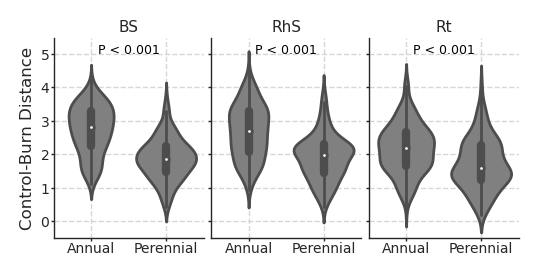

In [3]:
# Plot distances 
longdf = pd.read_csv(f'{GEMELLI}/Pooled/Distances_melted.tsv', sep='\t')
longdf = longdf.loc[(longdf.ID1_Area=='Control') & (longdf.ID2_Area=='Burn')]
longdf = longdf.loc[(longdf.ID1_sType==longdf.ID2_sType) &
                    (longdf.ID1_Cycle==longdf.ID2_Cycle) &
                    (longdf.ID1_Species==longdf.ID2_Species)]

longdf['Pair'] = longdf['ID1'] +'_'+ longdf['ID2']
for ind in longdf.index:
    longdf.loc[ind, 'Pair'] = '_'.join(longdf.loc[ind, 'Pair'].split('_'))
longdf['Pair'] = longdf.Pair.apply(lambda x: '_'.join(sorted(x.split('_'))))
ymin, ymax = longdf['Distance'].min(), longdf['Distance'].max()
test = pd.DataFrame()

#set figure
rows = 1
cols = len(MDICT)

fig, axes = plt.subplots(rows, cols, figsize=(3, 1.3), sharey='row', 
                         gridspec_kw={'wspace': .05, 'hspace': .04}, )

#test
for i, st in enumerate(MDICT):
    df = longdf.loc[(longdf.ID1_sType==st)].copy()
    x, y = df.loc[df.ID1_Cycle=='Annual']['Distance'].tolist(), df.loc[df.ID1_Cycle=='Perennial']['Distance'].tolist()
    test.loc[st, ['Stats', 'Pval']] = stats.kruskal(x, y)
test['P-adj'] = multipletests(test.Pval, method='fdr_bh')[1]

    
for i, st in enumerate(MDICT):
    df = longdf.loc[(longdf.ID1_sType==st)].copy()
    ax = axes[i]
    sns.violinplot(x='ID1_Cycle', y="Distance", data=df, ax=ax, order=SDICT, color='grey',
                  linewidth=1, )

    ax.tick_params(axis='both', labelsize=5, pad=.5, length=1, width=0.5 )
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.grid(lw=.5, ls='--', alpha=0.8) 
    if st == list(MDICT.keys())[0]:
        ax.set_ylabel('Control-Burn Distance', fontsize=6, labelpad=2)

    ax.text(.5, 1.03, st, ha='center', fontsize=5.5, transform=ax.transAxes)
    ax.set_ylim(-.5, ymax*1.2)
    ax.spines[['right', 'top']].set_visible(False)

    # add P-general
    p_gen = round(test.loc[st, 'P-adj'], 3)
    p = f'P = {p_gen}'
    if p_gen == 0:
        p = f'P < 0.001'
    c = 'black' if p_gen < .05 else 'dimgrey'
    ax.text(.5, .92, p, ha='center', fontsize=4.5, transform=ax.transAxes, c=c)

plt.savefig(f'Figures/Area_distances.svg')
plt.savefig(f'Figures/Area_distances.png')

## By species

### Gemelli RPCA

In [ ]:
for sp in SPECIES:
    retain = f"[Species]='{sp.replace('_', '. ')}'"
    
    #filter by metadata
    !qiime feature-table filter-samples \
        --i-table {TABLE} \
        --m-metadata-file metadata.tsv \
        --p-where "$retain" \
        --o-filtered-table {TABS}/{sp}_table.qza
   
    #Run Gemeli RPCA
    !qiime gemelli rpca \
        --i-table {TABS}/{sp}_table.qza \
        --output-dir {GEMELLI}/{sp}
    
    #create biplot
    !qiime emperor biplot \
        --i-biplot {GEMELLI}/{sp}/biplot.qza \
        --m-sample-metadata-file metadata.tsv \
        --o-visualization {GEMELLI}/{sp}/biplot.qzv \
        --p-number-of-features 5 

### Adonis

In [ ]:
dfs = []
for sp in SPECIES:
    qza = f'{GEMELLI}/{sp}/distance_matrix.qza'
    formula = "'sType + Area + PID'"
    pairs = ['sType']
    summ = run_adonis_strata(qza, META, formula, pairwise=pairs, strata='Forestry')
    summ['Species'] = sp
    dfs.append(summ)

summ = pd.concat(dfs)
summ['Metric'] = 'RPCA'
summ.to_csv(f'{adonis_out}/By_Species_adonis.tsv', sep='\t')
summ

### PCoA plots

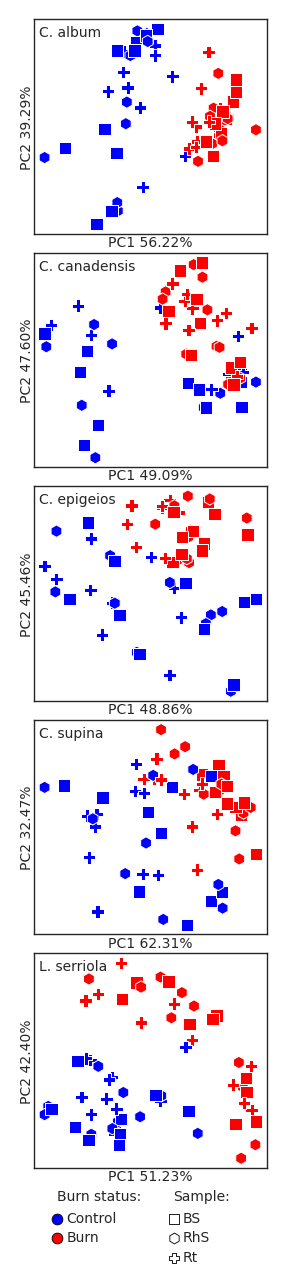

In [3]:
x, y = 1, 2 # axes to plot
show = ['Forestry', 'sType', 'Area']
cols = 1
rows = len(SPECIES) + 1

fig, axes = plt.subplots(rows, cols, figsize=(1.5, 8), 
                         gridspec_kw={'hspace': .1, 'height_ratios': [1,1,1,1,1,.3]})

for i, sp in enumerate(SPECIES):
    ordin, Prop = parse_pcoa(f'{GEMELLI}/{sp}/biplot.qza')
    ordin[show] = META[show]
    ax = axes[i]
    plot = sns.scatterplot(x=x, y=y, data=ordin, ax=ax, legend=False, 
                           hue='Area', palette=CDICT, s=20,
                           style='sType', markers=MDICT)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f'PC{y:d} {Prop[y-1]*100:.2f}%', fontsize=5, labelpad=0)
    ax.set_xlabel(f'PC{x:d} {Prop[x-1]*100:.2f}%', fontsize=5, labelpad=.5)
    ax.text(.02, .92, sp.replace('_', '. '), fontsize=5, ha='left', transform=ax.transAxes)

    #invert axes
    if sp == 'C_album':
        ax.xaxis.set_inverted(True)
    if sp == 'C_epigeios':
        ax.yaxis.set_inverted(True)
    if sp == 'L_serriola':
        ax.xaxis.set_inverted(True)

# legend
ax = axes[-1]
ax.axis('off')
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)
ystep, xstep = .3, 1
fsize = 5

#color
yax, xax = .8, .1
ax.text(xax, yax, 'Burn status:', fontsize=fsize)
for k,v in CDICT.items():
    yax -= ystep
    sns.scatterplot(x=[xax], y=[yax], ax=ax, s=15, clip_on=False, c=v, 
                    marker='o', edgecolor='black')
    ax.text(xax+.04, yax -.05, k, fontsize=fsize)

#style
yax, xax = .8, .6
ax.text(xax, yax, 'Sample:', fontsize=fsize)
for k,v in MDICT.items():
    yax -= ystep
    sns.scatterplot(x=[xax], y=[yax], ax=ax, s=15, clip_on=False, c='white', 
                    marker=v, edgecolor='black')
    ax.text(xax+.04, yax -.05, k, fontsize=fsize)

    
plt.savefig(f'Figures/PCoA_BySpecies.svg')
plt.savefig(f'Figures/PCoA_BySpecies.png')

## Cycle by area

### Gemelli RPCA

In [ ]:
for area in CDICT:
    retain = f"[Area]='{area}'"
    
    #filter by metadata
    !qiime feature-table filter-samples \
        --i-table {TABLE} \
        --m-metadata-file metadata.tsv \
        --p-where "$retain" \
        --o-filtered-table {TABS}/{area}_table.qza
   
    #Run Gemeli RPCA
    !qiime gemelli rpca \
        --i-table {TABS}/{area}_table.qza \
        --output-dir {GEMELLI}/{area}
    
    #create biplot
    !qiime emperor biplot \
        --i-biplot {GEMELLI}/{area}/biplot.qza \
        --m-sample-metadata-file metadata.tsv \
        --o-visualization {GEMELLI}/{area}/biplot.qzv \
        --p-number-of-features 5 

### Adonis

In [ ]:
dfs = []
for area in CDICT:
    qza = f'{GEMELLI}/{area}/distance_matrix.qza'
    formula = "'sType + Cycle + PID'"
    pairs = ['sType']
    summ = run_adonis_strata(qza, META, formula, pairwise=pairs, strata='Forestry')
    summ['Area'] = area
    dfs.append(summ)

summ = pd.concat(dfs)
summ['Metric'] = 'RPCA'
summ.to_csv(f'{adonis_out}/By_Area_adonis.tsv', sep='\t')
summ

### PCoA plots

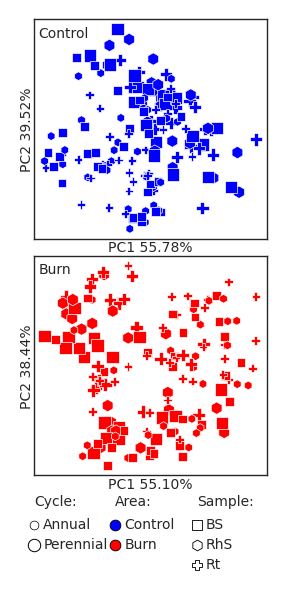

In [5]:
x, y = 1, 2 # axes to plot
show = ['Forestry', 'sType', 'Area', 'Cycle']
cols = 1
rows = len(CDICT) + 1

fig, axes = plt.subplots(rows, cols, figsize=(1.5, 3.5), 
                         gridspec_kw={'hspace': .1, 'height_ratios': [1,1,.3]})

for i, area in enumerate(CDICT):
    ordin, Prop = parse_pcoa(f'{GEMELLI}/{area}/biplot.qza')
    ordin[show] = META[show]
    ax = axes[i]
    plot = sns.scatterplot(x=x, y=y, data=ordin, ax=ax, legend=False, 
                           hue='Area', palette=CDICT,
                           style='sType', markers=MDICT,
                           size='Cycle', sizes=SDICT)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f'PC{y:d} {Prop[y-1]*100:.2f}%', fontsize=5, labelpad=0)
    ax.set_xlabel(f'PC{x:d} {Prop[x-1]*100:.2f}%', fontsize=5, labelpad=.5)
    ax.text(.02, .92, area, fontsize=5, ha='left', transform=ax.transAxes)


# legend
ax = axes[-1]
ax.axis('off')
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)
ystep, xstep = .3, 1
fsize = 5

#size
yax, xax = .8, 0
ax.text(xax, yax, 'Cycle:', fontsize=fsize)
for k,v in SDICT.items():
    yax -= ystep
    sns.scatterplot(x=[xax], y=[yax], ax=ax, s=v, clip_on=False, c='white', 
                    marker='o', edgecolor='black')
    ax.text(xax+.04, yax -.05, k, fontsize=fsize)

#color
yax, xax = .8, .35
ax.text(xax, yax, 'Area:', fontsize=fsize)
for k,v in CDICT.items():
    yax -= ystep
    sns.scatterplot(x=[xax], y=[yax], ax=ax, s=15, clip_on=False, c=v, 
                    marker='o', edgecolor='black')
    ax.text(xax+.04, yax -.05, k, fontsize=fsize)

#style
yax, xax = .8, .7
ax.text(xax, yax, 'Sample:', fontsize=fsize)
for k,v in MDICT.items():
    yax -= ystep
    sns.scatterplot(x=[xax], y=[yax], ax=ax, s=15, clip_on=False, c='white', 
                    marker=v, edgecolor='black')
    ax.text(xax+.04, yax -.05, k, fontsize=fsize)

    
plt.savefig(f'Figures/PCoA_ByArea.svg')
plt.savefig(f'Figures/PCoA_ByArea.png')

## Cycle by area and sample-type

### Gemelli RPCA

In [ ]:
for area in CDICT:
    for st in MDICT:
        retain = f"[Area]='{area}' AND [sType]='{st}'"
        
        #filter by metadata
        !qiime feature-table filter-samples \
            --i-table {TABLE} \
            --m-metadata-file metadata.tsv \
            --p-where "$retain" \
            --o-filtered-table {TABS}/{area}-{st}_table.qza
       
        #Run Gemeli RPCA
        !qiime gemelli rpca \
            --i-table {TABS}/{area}-{st}_table.qza \
            --output-dir {GEMELLI}/{area}-{st}
        
        #create biplot
        !qiime emperor biplot \
            --i-biplot {GEMELLI}/{area}-{st}/biplot.qza \
            --m-sample-metadata-file metadata.tsv \
            --o-visualization {GEMELLI}/{area}-{st}/biplot.qzv \
            --p-number-of-features 5 

### Adonis

In [6]:
dfs = []
for area in CDICT:
    for st in MDICT:
        qza = f'{GEMELLI}/{area}-{st}/distance_matrix.qza'
        formula = "'Cycle'"
        summ = run_adonis_strata(qza, META, formula, )
        summ[['Area', 'sType']] = area, st
        dfs.append(summ)

summ = pd.concat(dfs)
summ['Metric'] = 'RPCA'
summ.to_csv(f'{adonis_out}/By_Area_and_sType_adonis.tsv', sep='\t')
summ

,Df,SumsOfSqs,MeanSqs,F.Model,R2,Pr(>F),Formula,Mode,Area,sType,Metric
Factor,,,,,,,,,,,
Cycle,1,20.255176,20.255176,10.701772,0.182307,0.001,'Cycle',General,Control,BS,RPCA
Cycle,1,26.149890,26.149890,14.452368,0.231414,0.001,'Cycle',General,Control,RhS,RPCA
Cycle,1,24.996079,24.996079,14.194501,0.228228,0.001,'Cycle',General,Control,Rt,RPCA
Cycle,1,12.204351,12.204351,6.226419,0.114823,0.005,'Cycle',General,Burned,BS,RPCA
Cycle,1,12.178602,12.178602,6.158671,0.113715,0.004,'Cycle',General,Burned,RhS,RPCA
Cycle,1,15.622818,15.622818,7.961299,0.142264,0.001,'Cycle',General,Burned,Rt,RPCA


### PCoA plots

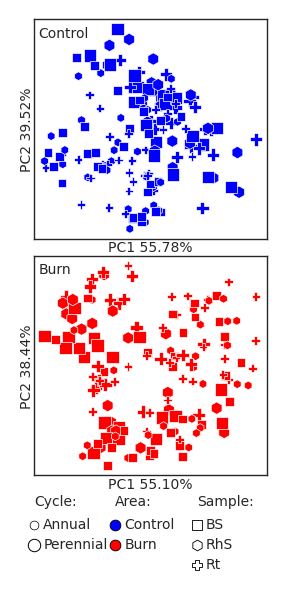

In [6]:
x, y = 1, 2 # axes to plot
show = ['Forestry', 'sType', 'Area', 'Cycle']
cols = 1
rows = len(CDICT) + 1

fig, axes = plt.subplots(rows, cols, figsize=(1.5, 3.5), 
                         gridspec_kw={'hspace': .1, 'height_ratios': [1,1,.3]})

for i, area in enumerate(CDICT):
    ordin, Prop = parse_pcoa(f'{GEMELLI}/{area}/biplot.qza')
    ordin[show] = META[show]
    ax = axes[i]
    plot = sns.scatterplot(x=x, y=y, data=ordin, ax=ax, legend=False, 
                           hue='Area', palette=CDICT,
                           style='sType', markers=MDICT,
                           size='Cycle', sizes=SDICT)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel(f'PC{y:d} {Prop[y-1]*100:.2f}%', fontsize=5, labelpad=0)
    ax.set_xlabel(f'PC{x:d} {Prop[x-1]*100:.2f}%', fontsize=5, labelpad=.5)
    ax.text(.02, .92, area, fontsize=5, ha='left', transform=ax.transAxes)

# legend
ax = axes[-1]
ax.axis('off')
ax.set_ylim(0, 1)
ax.set_xlim(0, 1)
ystep, xstep = .3, 1
fsize = 5

#size
yax, xax = .8, 0
ax.text(xax, yax, 'Cycle:', fontsize=fsize)
for k,v in SDICT.items():
    yax -= ystep
    sns.scatterplot(x=[xax], y=[yax], ax=ax, s=v, clip_on=False, c='white', 
                    marker='o', edgecolor='black')
    ax.text(xax+.04, yax -.05, k, fontsize=fsize)

#color
yax, xax = .8, .35
ax.text(xax, yax, 'Area:', fontsize=fsize)
for k,v in CDICT.items():
    yax -= ystep
    sns.scatterplot(x=[xax], y=[yax], ax=ax, s=15, clip_on=False, c=v, 
                    marker='o', edgecolor='black')
    ax.text(xax+.04, yax -.05, k, fontsize=fsize)

#style
yax, xax = .8, .7
ax.text(xax, yax, 'Sample:', fontsize=fsize)
for k,v in MDICT.items():
    yax -= ystep
    sns.scatterplot(x=[xax], y=[yax], ax=ax, s=15, clip_on=False, c='white', 
                    marker=v, edgecolor='black')
    ax.text(xax+.04, yax -.05, k, fontsize=fsize)

    
plt.savefig(f'Figures/PCoA_ByArea.svg')
plt.savefig(f'Figures/PCoA_ByArea.png')

# Alpha diversity

In [7]:
#parse formula. Borrowed from https://github.com/qiime2/q2-longitudinal
def parse_formula(formula): 
    from patsy import ModelDesc
    from statsmodels.formula.api import ols
    if '~' not in formula:
        raise ValueError('Formula not valid: missing tilde.\n')
    if ';' in formula or formula.strip()[0].isdigit():
        metric = formula.split('~')[0].strip()
    else: metric = None
    # use patsy to parse formula
    model_desc = ModelDesc.from_formula(formula)
    group_columns = set()
    for t in model_desc.rhs_termlist:
        for i in t.factors: 
            group_columns.add(i.name())
    if metric is None:
        metric = model_desc.lhs_termlist[0].name()
    return metric, group_columns

#anova
def run_anova(formula, data, pairs=False):
    import pandas as pd
    import statsmodels.api as sm
    from patsy import ModelDesc
    from statsmodels.formula.api import ols
    
    metric, group_columns = parse_formula(formula)
    columns  = [metric] + list(group_columns)
    cats = data.select_dtypes(exclude='number').columns.tolist()
    metadata = data[columns].dropna().copy()
    lm = ols(formula, metadata).fit()
    results = pd.DataFrame(sm.stats.anova_lm(lm, typ='II')).fillna('')
    # Run pairwise t-tests with multiple test correction
    pairwise_tests = pd.DataFrame()
    for group in group_columns:
        # only run on categorical columns — numeric columns raise error
        if group in cats:
            ttests = lm.t_test_pairwise(group, method='fdr_bh').result_frame
            pairwise_tests = pd.concat([pairwise_tests, pd.DataFrame(ttests)])
    if pairwise_tests.empty:
        pairwise_tests = False  
    # Plot fit vs. residuals
    metadata['residual'] = lm.resid
    metadata['fitted_values'] = lm.fittedvalues
    return results, pairwise_tests, metadata


#Wicoxon or ttest for 2 groups of dependent samples
def dependent_test(df, col, metric, index, method='wilcoxon'):
    data = df.pivot_table(index=[index], columns=col, values=metric)
    if method not in ['wilcoxon', 'ttest']:
        raise ValueError('Method should be either "wilcoxon" or "ttest"')
    if method == 'wilcoxon':
        out = stats.wilcoxon(data[data.columns[0]], data[data.columns[1]], nan_policy='omit')
    if method == 'ttest':
        out = stats.ttest_rel(data[data.columns[0]], data[data.columns[1]], nan_policy='omit')
    return out


#Kruskal-Wallis test
def kw_test(df, col, metric, pairs=False, pairwise=False):
    phoc = pd.DataFrame(columns=['Group1', 'Group2', 'Mean1', 'Mean2', 'Stats', 'p'])
    kw = stats.kruskal(*[g[metric].values for n, g in df.groupby(col)])
    if kw[1] <= 0.05 and pairwise == True:
        if pairs == False: 
            pairs = combinations(df[col].unique(), 2)
        for pair in pairs:
            one = df.loc[df[col] == pair[0], metric].tolist()
            two = df.loc[df[col] == pair[1], metric].tolist()
            if min(one) == max(one) == min(two) == max(two) == 0:
                continue
            r, p = stats.kruskal(one, two)
            phoc.loc[len(phoc)] = [pair[0], pair[1], np.average(one), np.average(two), r, p]
        phoc['q'] = multipletests(phoc.p, method='fdr_bh')[1]
    return kw, phoc
    
    
out = 'Results/Alpha_test'

!mkdir -p $out Figures/Alpha_diversity

## Add alpha metrics to metadata file

In [8]:
def add_alpha(qza):  
    a = !unzip $qza
    out = a[1].split('/')[0].replace('  inflating: ', '')
    inf = f'{out}/data/alpha-diversity.tsv'
    df = pd.read_csv(inf, sep='\t', index_col=0)
    !rm -rf $out
    return df 


for alpha in ALPHAS:
    data = add_alpha(f'{COREM}/{alpha}_vector.qza')
    META.loc[data.index, alpha] = data.iloc[:, 0]

META
META.to_csv('metadata.tsv',sep='\t')

## Check normality of alpha metrics

In [ ]:
norm = pd.DataFrame(columns=['Metric', 'Stats', 'p'])

for alpha in ALPHAS:
    data = META[META[alpha].notna()].copy()
    i = len(norm)
    norm.loc[i, 'Metric'] = alpha
    norm.loc[i, ['Stats', 'p']] = [stats.shapiro(data[alpha])[0], stats.shapiro(data[alpha])[1]]

norm.to_csv(f'{out}/alpha_normality.tsv', sep='\t', index=False)    
norm

#p > 0.05 means normal distribution

## Pooled

In [ ]:
facts = ['Species', 'sType', 'Area', 'Forestry']
summary = pd.DataFrame()

for alpha in ALPHAS:
    data = META[(META[alpha].notna())].copy()
    for fact in facts:
        kw, phoc = kw_test(data, fact, alpha, pairwise=True)
        if kw[1] <= 0.05:
            for ind in phoc.index:
                i = len(summary)
                summary.loc[i, ['Metric', 'Factor']] = alpha, fact
                summary.loc[i, ['KW', 'Stats']] = kw[1], kw[0]
                summary.loc[i, ['Group1', 'Group2']] = phoc.loc[ind, ['Group1', 'Group2']]
                summary.loc[i, ['p', 'q']] = phoc.loc[ind, ['p', 'q']]
        else:
            i = len(summary)
            summary.loc[i, ['Metric', 'Factor']] = alpha, fact
            summary.loc[i, ['KW', 'Stats']] = kw[1], kw[0]
            summary.loc[i, ['Group1', 'Group2', 'p', 'q']] = np.NaN,np.NaN,np.NaN,np.NaN

display(summary)
summary.to_csv(f'{out}/Pooled_KW.tsv', sep='\t', index=False)

## By species and sType

In [ ]:
summary = pd.DataFrame()

for sp in SPECIES:
    md = META.loc[(META.Species == sp.replace('_', '. '))]    
    for alpha in ALPHAS:
        for st in MDICT:
            data = md.loc[(md[alpha].notna()) & (md.sType == st)]
            kw, phoc = kw_test(data, 'Area', alpha, pairwise=True)
            if kw[1] <= 0.05:
                for ind in phoc.index:
                    i = len(summary)
                    summary.loc[i, ['Species', 'sType', 'Metric', 'Factor']] = sp, st, alpha, 'Area'
                    summary.loc[i, ['KW', 'Stats']] = kw[1], kw[0]
                    summary.loc[i, ['Group1', 'Group2']] = phoc.loc[ind, ['Group1', 'Group2']]
                    summary.loc[i, ['p', 'q']] = phoc.loc[ind, ['p', 'q']]
            else:
                i = len(summary)
                summary.loc[i, ['Species', 'sType', 'Metric', 'Factor']] = sp, st, alpha, 'Area'
                summary.loc[i, ['KW', 'Stats']] = kw[1], kw[0]
                summary.loc[i, ['Group1', 'Group2', 'p', 'q']] = '-','-',np.NaN,np.NaN

display(summary)
summary.to_csv(f'{out}/BySpesies_and_sType_KW.tsv', sep='\t', index=False)

### Boxplots

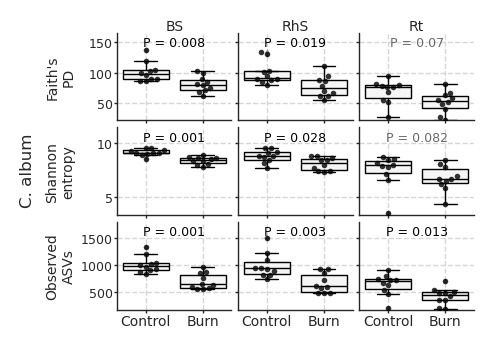

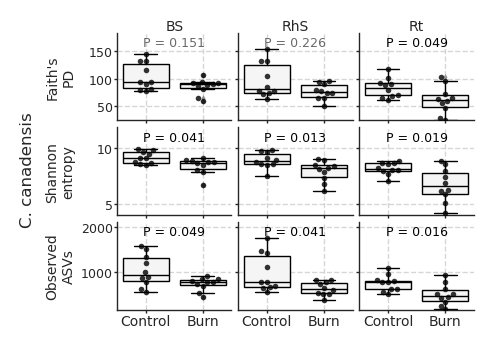

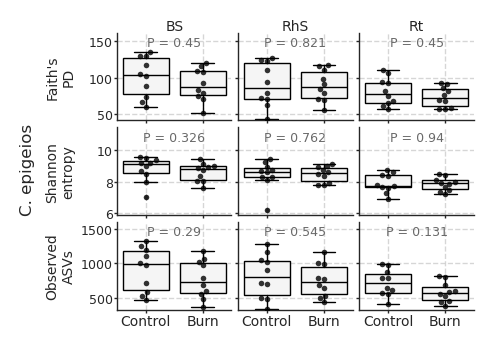

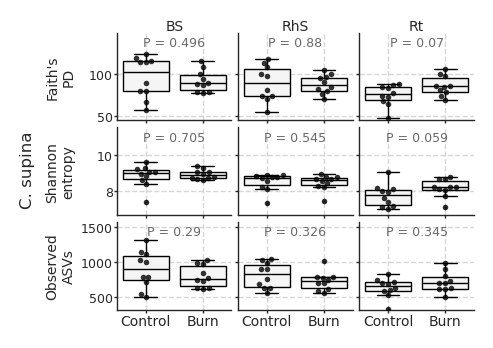

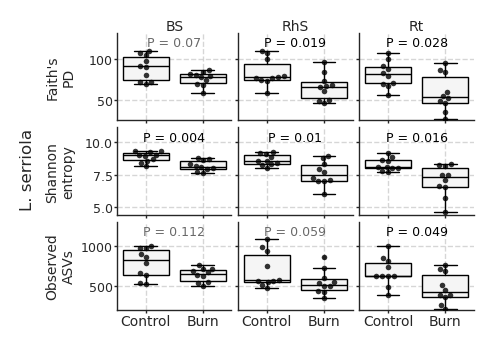

In [11]:
import warnings # To suppress some warnings
# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

#set figure
alphas = ('faith_pd', 'shannon', 'observed_features')
rows = len(alphas)
cols = len(MDICT)
summary = pd.read_csv(f'{out}/BySpesies_and_sType_KW.tsv', sep='\t')


for sp in SPECIES:
    md = META.loc[(META.Species == sp.replace('_', '. '))]
    
    fig, axes = plt.subplots(rows, cols, figsize=(2.3, 1.8), sharey='row', sharex='col',
                             gridspec_kw={'wspace': .06, 'hspace': .08}, )
    axs, i = [[r, c] for r in range(rows) for c in range(cols)], 0
    
    for alpha in alphas:
        ymin, ymax = md[alpha].min(), md[alpha].max()
        for st in MDICT:
            data = md.loc[(md[alpha].notna()) & (md.sType == st)]

            #boxplots/dotplots
            ax, i = axes[axs[i][0]][axs[i][1]], i+1
            sns.boxplot(x='Area', y=alpha, data=data, ax=ax, linewidth=0.4, fliersize=0.3, 
                        order=CDICT, color='whitesmoke', showfliers=True)
            sns.swarmplot(x='Area', y=alpha, data=data, order=CDICT, ax=ax, size=2, 
                          alpha=0.8, legend=False, color='black')

            ax.tick_params(axis='both', labelsize=4.5, pad=.5, length=1, width=0.5 )
            ax.tick_params(axis='x', labelsize=5)
            ax.set_ylabel('')
            ax.set_xlabel('')
            ax.grid(lw=.5, ls='--', alpha=0.8) 
            if st == list(MDICT.keys())[0]:
                ax.set_ylabel(ALPHAS[alpha], fontsize=5, labelpad=2)
            if alpha == alphas[0]:
                ax.text(.5, 1.03, st, ha='center', fontsize=5, transform=ax.transAxes)
            ax.set_ylim(ymin*.95, ymax*1.2)

            #line color/width
            for patch in ax.patches:
                patch.set_edgecolor('black')
                patch.set_linewidth(.5)
            plt.setp(ax.lines, color='k', lw=.5)
            ax.spines[['right', 'top']].set_visible(False)

            # add P-general
            summ = summary.loc[(summary.Metric == alpha) & 
                               (summary.Species == sp) &
                               (summary.sType == st)]
            p_gen = round(summ.KW.iloc[0], 3)
            p = f'P = {p_gen}'
            if p_gen == 0:
                p = f'P < 0.001'
            c = 'black' if p_gen < .05 else 'dimgrey'
            ax.text(.5, .85, p, ha='center', fontsize=4.5, transform=ax.transAxes, c=c)

    fig.align_labels()
    fig.suptitle(x=-0.07, y=0.5, t=sp.replace('_', '. '), fontsize=6, rotation=90, va='center')

    plt.savefig(f'Figures/Alpha_{sp}.svg')
    #plt.savefig(f'Figures/Alpha_{sp}.png')

## By Area and sType

In [ ]:
summary = pd.DataFrame()

for area in CDICT:
    md = META.loc[(META.Area == area)]  
    for alpha in ALPHAS:
        for st in MDICT:
            data = md.loc[(md[alpha].notna()) & (md.sType == st)]
            kw, phoc = kw_test(data, 'Cycle', alpha, pairwise=True)
            if kw[1] <= 0.05:
                for ind in phoc.index:
                    i = len(summary)
                    summary.loc[i, ['Area', 'sType', 'Metric', 'Factor']] = area, st, alpha, 'Cycle'
                    summary.loc[i, ['KW', 'Stats']] = kw[1], kw[0]
                    summary.loc[i, ['Group1', 'Group2']] = phoc.loc[ind, ['Group1', 'Group2']]
                    summary.loc[i, ['p', 'q']] = phoc.loc[ind, ['p', 'q']]
            else:
                i = len(summary)
                summary.loc[i, ['Area', 'sType', 'Metric', 'Factor']] = area, st, alpha, 'Cycle'
                summary.loc[i, ['KW', 'Stats']] = kw[1], kw[0]
                summary.loc[i, ['Group1', 'Group2', 'p', 'q']] = '-','-',np.NaN,np.NaN

display(summary)
summary.to_csv(f'{out}/ByArea_and_sType_KW.tsv', sep='\t', index=False)

### Boxplots

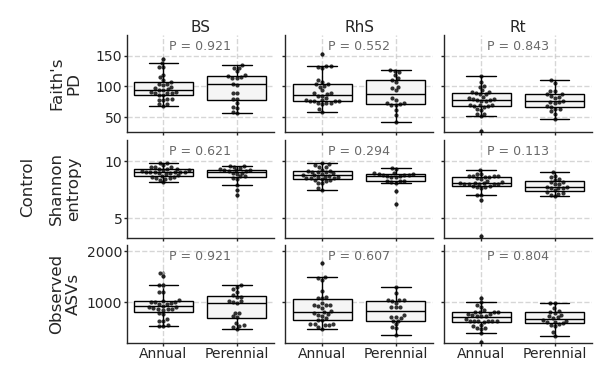

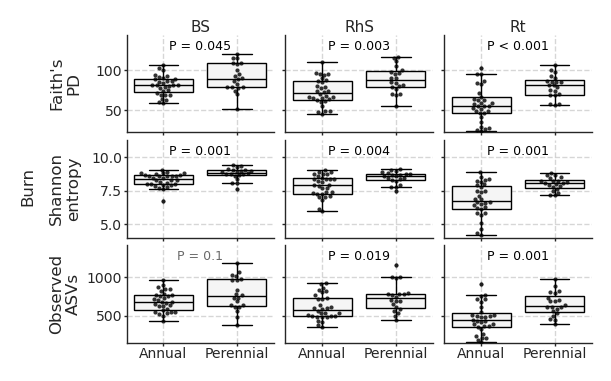

In [13]:
import warnings # To suppress some warnings
# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

#set figure
alphas = ('faith_pd', 'shannon', 'observed_features')
rows = len(alphas)
cols = len(MDICT)
summary = pd.read_csv(f'{out}/ByArea_and_sType_KW.tsv', sep='\t')

for area in CDICT:
    md = META.loc[(META.Area == area)]
    
    fig, axes = plt.subplots(rows, cols, figsize=(3, 2), sharey='row', sharex='col',
                             gridspec_kw={'wspace': .08, 'hspace': .08}, )
    axs, i = [[r, c] for r in range(rows) for c in range(cols)], 0
    
    for alpha in alphas:
        ymin, ymax = md[alpha].min(), md[alpha].max()
        for st in MDICT:
            data = md.loc[(md[alpha].notna()) & (md.sType == st)]

            #boxplots/dotplots
            ax, i = axes[axs[i][0]][axs[i][1]], i+1
            sns.boxplot(x='Cycle', y=alpha, data=data, ax=ax, linewidth=0.4, fliersize=0.3, 
                        order=SDICT, color='whitesmoke', showfliers=True)
            sns.swarmplot(x='Cycle', y=alpha, data=data, order=SDICT, ax=ax, size=1.5, 
                          alpha=0.8, legend=False, color='black')

            ax.tick_params(axis='both', labelsize=5, pad=.5, length=1, width=0.5 )
            #ax.tick_params(axis='x', rotation=90)
            ax.set_ylabel('')
            ax.set_xlabel('')
            ax.grid(lw=.5, ls='--', alpha=0.8) 
            if st == list(MDICT.keys())[0]:
                ax.set_ylabel(ALPHAS[alpha], fontsize=6, labelpad=2)
            if alpha == alphas[0]:
                ax.text(.5, 1.03, st, ha='center', fontsize=5.5, transform=ax.transAxes)
            ax.set_ylim(ymin*.95, ymax*1.2)

            #line color/width
            for patch in ax.patches:
                patch.set_edgecolor('black')
                patch.set_linewidth(.5)
            plt.setp(ax.lines, color='k', lw=.5)
            ax.spines[['right', 'top']].set_visible(False)

            # add P-general
            summ = summary.loc[(summary.Metric == alpha) & 
                               (summary.Area == area) &
                               (summary.sType == st)]
            p_gen = round(summ.KW.iloc[0], 3)
            p = f'P = {p_gen}'
            if p_gen == 0:
                p = f'P < 0.001'
            c = 'black' if p_gen < .05 else 'dimgrey'
            ax.text(.5, .85, p, ha='center', fontsize=4.5, transform=ax.transAxes, c=c)

    fig.align_labels()
    fig.suptitle(x=-0.04, y=0.5, t=area, fontsize=6, rotation=90, va='center')

    plt.savefig(f'Figures/Alpha_{area}.svg')
    #plt.savefig(f'Figures/Alpha_{area}.png')

# Taxabarplots

In [ ]:
!mkdir -p Results/Taxabarplots

!qiime taxa barplot \
    --i-table {TABLE} \
    --i-taxonomy {TAXA} \
    --m-metadata-file metadata.tsv \
    --o-visualization Results/Taxabarplots/taxabarplot.qzv

## Import libraries and declare variables

In [14]:
colours = cc.glasbey_light

def bar_unzip(qza, lev):    
    a = !unzip $qza
    digest = a[1].split('/')[0].replace('  inflating: ', '')
    inf = digest + f'/data/level-{lev}.csv'
    data = pd.read_csv(inf, sep=',', index_col=0)
    !rm -rf $digest
    return data

## Plot Taxabarplots

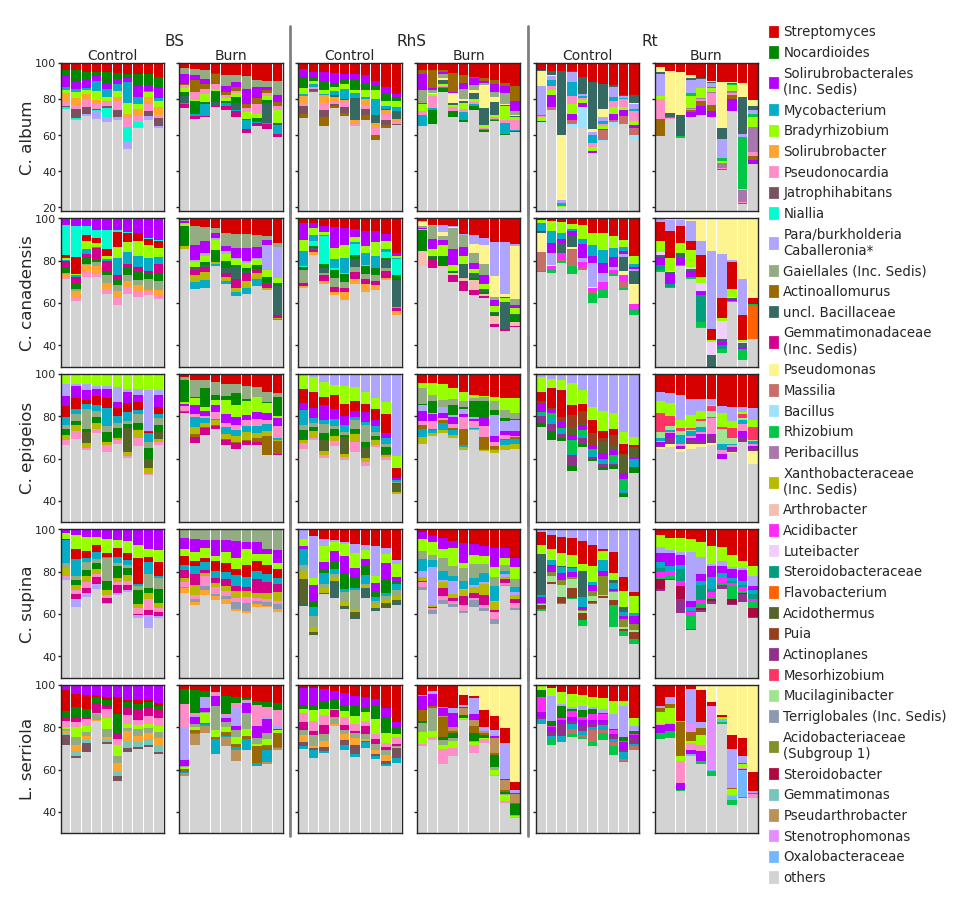

In [15]:
top = 10
rows = len(SPECIES)
cols = len(MDICT)*2

drep = {
    '_': ' ',
    ';': ' ',
    'Burkholderia-Caballeronia-Paraburkholderia': 'Para/burkholderia\nCaballeronia*',
    'Solirubrobacterales f  67-14 g  Incertae Sedis': 'Solirubrobacterales\n(Inc. Sedis)',
    'f  Bacillaceae': 'f  uncl. Bacillaceae',
    'Gaiellales f  Incertae Sedis g  Incertae Sedis': 'Gaiellales (Inc. Sedis)',
    'ceae g  Incertae Sedis': 'ceae (Inc. Sedis)',
    'Acidobacteriaceae (Subgroup 1) g  Incertae Sedis': 'Acidobacteriaceae\n(Subgroup 1)',
    'les f  Incertae Sedis g  Incertae Sedis': 'les (Inc. Sedis)',
    'Chloroflexota c  KD4-96 o  Incertae Sedis f  Incertae Sedis g  Incertae Sedis': 'Chloroflexota (KD4-96)',
    'Gemmatimonadaceae (Inc. Sedis)': 'Gemmatimonadaceae\n(Inc. Sedis)',
    'Xanthobacteraceae (Inc. Sedis)': 'Xanthobacteraceae\n(Inc. Sedis)',
}

df = bar_unzip(f'Results/Taxabarplots/taxabarplot.qzv', 6)
df = df[[col for col in df.columns if 'p__' in col]]
meta = META.loc[df.index].copy()
df = df.loc[meta.index].copy()  
df = df.div(df.sum(axis=1), axis=0) * 100 #convert to % (rel ab)
df.to_csv(f'Results/Taxabarplots/Genera.tsv', sep='\t')

#legend
tracker = []
cdict = {}

#figure
fig, axes = plt.subplots(rows, cols, figsize=(4.5, 5), sharey='row',
                         gridspec_kw={'wspace': .15, 'hspace': .05})
axs, i = [[r, c] for r in range(rows) for c in range(cols)], 0

for sp in SPECIES:
    for st in MDICT:
        for area in CDICT:
            meta = META.loc[(META.Species==sp.replace('_','. '))&(META.sType==st)&(META.Area==area)]
            temp = df.loc[meta.index]
            temp = temp.reindex(temp.mean().sort_values(ascending=False).index, axis=1)
            temp = temp[temp.columns.tolist()[:top]]
            data = temp.copy()
            #display(data)
            for k, v in drep.items():
                data.columns = [c.replace(k, v) for c in data.columns]
            data.columns = [c.strip(' ').split('  ')[-1] for c in data.columns]
            data = data.sort_values(data.columns[0])
            data.to_csv(f'Results/Taxabarplots/{sp}-{st}-{area}-Genera_5.tsv', sep='\t')

            #plot
            ax, i = axes[axs[i][0]][axs[i][1]], i+1
            bottom = [100 for j in data.index] 
            ax.bar(x=data.index, height=bottom, color='lightgrey', width=.92, linewidth=0)
            
            for col in data.columns: #iterate through all features
                if col not in tracker:
                    #if col == 'Incertae Sedis':
                    #    display(temp.columns.tolist())
                    tracker.append(col)
                    cdict.update({col: colours[tracker.index(col)]})
                c = cdict[col]
                bottom = [a - b for a, b in zip(bottom, list(data[col]))] #update bottom
                ax.bar(x=data.index, height=data[col], bottom=bottom, color=c, label=col, width=.92, linewidth=0)

            #aesthetics
            ax.tick_params(axis='both', labelsize=4, pad=.5, length=1, width=0.5) #adjust ticks
            ax.set_xticks([])
            ylim = 18 if sp == SPECIES[0] else 30
            ax.set_ylim(ylim, 100) #set limit for y axis
            ax.set_xlim(-.5, len(data.index) - .5) #set limit for x axis
            ax.set_ylabel('', fontsize=5.5, labelpad=0)
            if st == list(MDICT.keys())[0] and area == list(CDICT.keys())[0]:
                ax.set_ylabel(sp.replace('_', '. '), fontsize=6, labelpad=0)
            if sp == SPECIES[0]:
                ax.text(.5, 1.02, area, ha='center', fontsize=5, transform=ax.transAxes)

            #add vlines
            if area == list(CDICT.keys())[-1]:
                if sp == SPECIES[0]:
                    ax.text(-.05, 1.1, st, ha='center', fontsize=5.5, transform=ax.transAxes, va='bottom')
                if st != list(MDICT.keys())[-1]:
                    ax.plot([1.075, 1.075], [-0.02, 1.25], transform=ax.transAxes, clip_on=False, color='grey', lw=1.)
                    
#legend
labels = tracker + ['others']                     
handles = [mpatches.Patch(color='lightgrey', label=l) if l == 'others' \
          else mpatches.Patch(color=cdict[l], label=l) for l in labels]

leg = ax.legend(handles, labels, loc=2, bbox_to_anchor=(.9, .93), fontsize=4.8, frameon=False,
                handletextpad=0.5, handlelength=0.5, bbox_transform=fig.transFigure) 

plt.savefig(f'Figures/Taxabarplot_Species.svg')
plt.savefig(f'Figures/Taxabarplot_Species.png')

# ANCOM BC Genera

In [4]:
#get effect sizes, q-values and errors
def ancombc_unzip(qza):    
    a = !unzip $qza
    out = a[1].split('/')[0].replace('  inflating: ', '')
    lfc = pd.read_csv(f'{out}/data/lfc_slice.csv', sep=',')
    qval = pd.read_csv(f'{out}/data/q_val_slice.csv', sep=',')
    se = pd.read_csv(f'{out}/data/se_slice.csv', sep=',')
    !rm -rf $out
    return lfc, qval, se

### Area by Species and sType

In [ ]:
#run AncomBC

outdir = f'Results/Ancom-BC-Genera'

!mkdir -p $outdir

for sp in SPECIES:
    for st in MDICT:
        retain = f"[sType]='{st}'"
        
        #filter by metadata
        !qiime feature-table filter-samples \
            --i-table {TABS}/{sp}_table.qza \
            --m-metadata-file metadata.tsv \
            --p-where "$retain" \
            --o-filtered-table {TABS}/{st}-{sp}_table.qza
    
        #Collapse to genera
        !qiime taxa collapse \
            --i-table {TABS}/{st}-{sp}_table.qza \
            --i-taxonomy {TAXA} \
            --p-level 6 \
            --o-collapsed-table {outdir}/{st}-{sp}_table.qza 
        
        #filer by relative abundances
        !qiime feature-table filter-features-conditionally \
            --i-table {outdir}/{st}-{sp}_table.qza \
            --p-abundance .01 \
            --p-prevalence .1 \
            --o-filtered-table {outdir}/{st}-{sp}_table.qza
        
        #run ancom-bc
        !qiime composition ancombc \
            --i-table {outdir}/{st}-{sp}_table.qza \
            --m-metadata-file metadata.tsv \
            --p-formula 'Area' \
            --p-reference-levels "Area::Control" \
            --o-differentials {outdir}/{st}-{sp}_diffs.qza
        
        #da-barplot
        !qiime composition da-barplot \
            --i-data {outdir}/{st}-{sp}_diffs.qza \
            --p-significance-threshold 0.05 \
            --o-visualization {outdir}/{st}-{sp}_ancom.qzv

In [ ]:
#merge Ancom-BC outputs

dfs = []
outdir = f'Results/Ancom-BC-Genera'

for sp in SPECIES:
    for st in MDICT:
        lfc, qval, se = ancombc_unzip(f'{outdir}/{st}-{sp}_diffs.qza')
        lfc = lfc.melt(id_vars='id', value_name='LFC', var_name='Level')
        qval = qval.melt(id_vars='id', value_name='qval', var_name='Level')
        se = se.melt(id_vars='id', value_name='SE', var_name='Level')
        lfc['qval'] = qval['qval']
        lfc['SE'] = se['SE']
        lfc = lfc.loc[~lfc.Level.isin(['(Intercept)'])]
        lfc.Level = lfc.Level.str.replace('Area', '')
        lfc[['sType', 'Species']] = st, sp
        dfs.append(lfc)
summ = pd.concat(dfs)
summ = summ.loc[summ['qval'] <= .05]
display(summ)
summ.to_csv(f'{outdir}/Area.tsv', sep='\t', index=False) 

In [ ]:
# plot ABC2

#dictionary to modify taxa IDs
drep = {
    '_': ' ',
    ';': ' ',
    'Burkholderia-Caballeronia-Paraburkholderia': 'Para/burkholderia Caballeronia*',
    'Solirubrobacterales f  67-14 g  Incertae Sedis': 'Solirubrobacterales (Inc. Sedis)',
    'f  Bacillaceae': 'f  uncl. Bacillaceae',
    'Gaiellales f  Incertae Sedis g  Incertae Sedis': 'Gaiellales (Inc. Sedis)',
    'Xanthobacteraceae g  Incertae Sedis': 'Xanthobacteraceae (Inc. Sedis)',
    'Gemmatimonadaceae g  Incertae Sedis': 'Gemmatimonadaceae (Inc. Sedis)',
    'f  Micromonosporaceae': 'f  uncl. Micromonosporaceae',
    'Saccharimonadales f  Incertae Sedis g  Incertae Sedis': 'Saccharimonadales (Inc. Sedis)',
    'f  Acidobacteriaceae (Subgroup 1) g  Incertae Sedis': 'f  Acidobacteriaceae (Inc. Sedis)',
    'f  Acetobacteraceae g  Incertae Sedis': 'f  Acetobacteraceae (Inc. Sedis)',
    'f  Micropepsaceae g  Incertae Sedis': 'f  Micropepsaceae (Inc. Sedis)',
    'f  Haliangiaceae g  Incertae Sedis': 'f  Haliangiaceae (Inc. Sedis)',
    'f  Pyrinomonadaceae g  Incertae Sedis': 'f  Pyrinomonadaceae (Inc. Sedis)',
    'o  Vicinamibacterales f  Incertae Sedis g  Incertae Sedis': 'o  Vicinamibacterales (Inc. Sedis)',
    'f  Chitinophagaceae g  Incertae Sedis': 'f  Chitinophagaceae (Inc. Sedis)',
    'p  Chloroflexota c  KD4-96 o  Incertae Sedis f  Incertae Sedis g  Incertae Sedis': 'p  Chloroflexota (KD4-96)',
    'p  Chloroflexota c  TK10 o  Incertae Sedis f  Incertae Sedis g  Incertae Sedis': 'p  Chloroflexota (TK10)',
    '  Actinomycetota c  MB-A2-108 o  Incertae Sedis f  Incertae Sedis g  Incertae Sedis': '  Actinomycetota (MB-A2-108)',
    'o  Burkholderiales f  SC-I-84 g  Incertae Sedis': 'o  Burkholderiales (Inc. Sedis)',
    'o  Elsterales f  Incertae Sedis g  Incertae Sedis': 'o  Elsterales (Inc. Sedis)',
    'f  Solirubrobacteraceae g  Incertae Sedis': 'f  Solirubrobacteraceae (Inc. Sedis)',
    'o  Polyangiales f  BIrii41 g  Incertae Sedis': 'o  Polyangiales (Inc. Sedis)',
    'f  Gemmataceae g  Incertae Sedis': 'f  Gemmataceae (Inc. Sedis)',
    'o  Terriglobales f  Incertae Sedis g  Incertae Sedis': 'o  Terriglobales (Inc. Sedis)',
    'c  Oligoflexia o  0319-6G20 f  Incertae Sedis g  Incertae Sedis': 'c  Oligoflexia (Inc. Sedis)',
    'Streptosporangiaceae': 'uncl. Streptosporangiaceae',
    'Pyrinomonadaceae': 'uncl. Pyrinomonadaceae',
    'Micrococcaceae': 'uncl. Micrococcaceae',
    'possible genus 04': 'Fibrobacteraceae (genus 04)',
    'c  Acidobacteriae o  Subgroup 2 f  Incertae Sedis g  Incertae Sedis': 'c  Acidobacteriae (Inc. Sedis)',
    'p  Myxococcota c  bacteriap25 o  Incertae Sedis f  Incertae Sedis g  Incertae Sedis': 'p  Myxococcota (Inc. Sedis)',
    'f  Sandaracinaceae g  Incertae Sedis': 'f  Sandaracinaceae (Inc. Sedis)',
    'o  Aggregatilineales f  A4b g  Incertae Sedis': 'o  Aggregatilineales (Inc. Sedis)',
    'f  Roseiflexaceae g  Incertae Sedis': 'f  Roseiflexaceae (Inc. Sedis)',
    'Xanthobacteraceae': 'uncl. Xanthobacteraceae',
    'f  Thermoanaerobaculaceae g  Subgroup 10': 'f  Thermoanaerobaculaceae (S10)',
    'Hyphomicrobiales': 'uncl. Hyphomicrobiales',
    'Chitinophagaceae': 'uncl. Chitinophagaceae',
}

cdict = {
    'Burn': 'red',
    'Control': 'blue',
}

#read summary
outdir = f'Results/Ancom-BC-Genera'
summ = pd.read_csv(f'{outdir}/Area.tsv', sep='\t', index_col=0)
summ = summ.loc[summ.LFC.abs() >= 2]
summ.sort_values(by='LFC', ascending=False, inplace=True)
summ['ID'] = summ.index.str.strip('__').str.strip(';')
summ['ID'] = summ.ID.str.strip('__').str.strip(';')
summ['ID'] = summ.ID.str.strip('__').str.strip(';')

#replace some susTypetrings in IDs
for k, v in drep.items():
    summ.ID = summ.ID.apply(lambda x: x.replace(k, v))
summ['ID'] = summ['ID'].str.split('  ').str[-1]
vmax, vmin = summ.LFC.max(), summ.LFC.min() #max and min values for cbar
averaged = summ.groupby(['ID']).mean()
averaged = averaged.sort_values(by='LFC', ascending=False)
yorder = averaged.index.unique().tolist()
#set fig scaling
S = 11 #scale figure size
H = len(yorder)/S #height of figure
W = 4
#W = len(MDICT)/1.2 #width of figure
step = 1/len(yorder) #height of 1 line

#set figure
cols = len(SPECIES)
rows = 1
fig, axes = plt.subplots(rows, cols, figsize=(W, H), sharey='row',
                         gridspec_kw={'wspace': .05})

for i, sp in enumerate(SPECIES):
    data = summ.loc[summ.Species == sp]
    sp = sp.replace('_', '. ')
    hdf = data.pivot(index='ID', columns='sType', values='LFC')

    #order columns
    for st in MDICT:
        if st not in hdf.columns:
            hdf[st] = np.nan
    hdf = hdf[list(MDICT.keys())]

    #order index
    hdf = hdf.reindex(yorder)
    
    #heatmap
    ax = axes[i]
    sns.heatmap(data=hdf, ax=ax, cbar_kws={'orientation':'horizontal'}, annot=True, cbar=False,
                square=False, center=0, cmap='seismic', xticklabels=True, yticklabels=True, 
                annot_kws={"size":4,}, linewidths=.3, linecolor='grey', vmax=vmax, vmin=vmin)

    #aesthetics
    ax.axhline(y=0, color='k', linewidth=.8)
    ax.axhline(y=len(hdf), color='k', linewidth=.8)
    ax.axvline(x=0, color='k', linewidth=.8)
    ax.axvline(x=len(hdf.columns), color='k', linewidth=.8)
    ax.set_xticks([])
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.tick_params(axis='both', which='both', labelsize=4.5, length=0, pad=1, rotation=0)
    ax.tick_params(axis='x', labelsize=4.5, pad=2, rotation=90,)
    ax.text(.5, 1.01, sp, ha='center', fontsize=5, transform=ax.transAxes)

    for j, lab in enumerate(MDICT):
        ax.text(j+.5, len(hdf)+.2, lab.replace('os', 'o-\ns'), va='top', ha='center', fontsize=5, 
                transform=ax.transData)

    #legend
    if i == 0:
        labels = list(cdict.keys())                    
        handles = [mpatches.Patch(color='lightgrey', label=l) if l == 'others' \
                  else mpatches.Patch(color=cdict[l], label=l) for l in labels]
        ax.legend(handles, labels, loc=2, fontsize=5, frameon=False, handletextpad=0.5, 
              handlelength=2, bbox_to_anchor=(0, -.02), bbox_transform=ax.transAxes, ncols=2)


fig.suptitle('Log fold change (LFC)', y=0.08, fontsize=5, )
plt.savefig(f'Figures/AncomBC-Area.svg')
plt.savefig(f'Figures/AncomBC-Area.png')

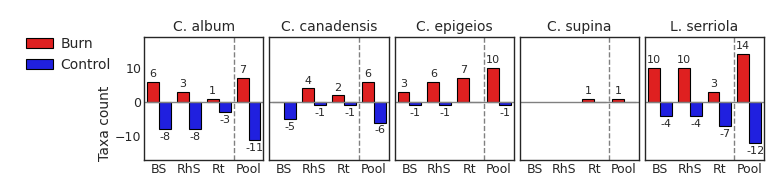

In [19]:
#plot summary

#read summary
outdir = f'Results/Ancom-BC-Genera'
summ = pd.read_csv(f'{outdir}/Area.tsv', sep='\t', index_col=0)
summ = summ.loc[summ.LFC.abs() >= 2]
summ.Species = summ.Species.str.replace('_', '. ')

### add sign. counts ###
sign_count = pd.DataFrame()

# by sample type and species
for st in MDICT:
    for sp in summ.Species.unique():
        df_sig = summ.loc[(summ.Species == sp) & (summ.sType == st)]
        if len(df_sig) == 0:
            continue
        j = len(sign_count)
        pos = df_sig.loc[df_sig.LFC > 0]
        neg = df_sig.loc[df_sig.LFC < 0]
        sign_count.loc[j, 'Contrast'] = 'Burn vs Control (ref)'
        sign_count.loc[j, 'sType'] = st
        sign_count.loc[j, 'Species'] = sp
        sign_count.loc[j, 'Sig'] = len(df_sig.index.unique())
        sign_count.loc[j, 'Burn'] = len(pos.index.unique())
        sign_count.loc[j, 'Control'] = len(neg.index.unique())*-1

# pooled by species
for sp in summ.Species.unique():
    df_sig = summ.loc[(summ.Species == sp)]
    if len(df_sig) == 0:
        continue
    j = len(sign_count)
    pos = df_sig.loc[df_sig.LFC > 0]
    neg = df_sig.loc[df_sig.LFC < 0]
    sign_count.loc[j, 'Contrast'] = 'Burned vs Control (ref)'
    sign_count.loc[j, 'sType'] = 'Pool'
    sign_count.loc[j, 'Species'] = sp
    sign_count.loc[j, 'Sig'] = len(df_sig.index.unique())
    sign_count.loc[j, 'Burn'] = len(pos.index.unique())
    sign_count.loc[j, 'Control'] = len(neg.index.unique())*-1  
    
sign_count.to_csv(f'{outdir}/ABC2_count.tsv', sep='\t')
    
#set figure
xorder = [k for k in MDICT] + ['Pool']
cols = len(SPECIES)
rows = 1
H = .8 #height of figure
W = 4 #width of figure

fig, axes = plt.subplots(rows, cols, figsize=(W, H), sharey='row',
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.05})

#Plot 
for i,sp in enumerate(SPECIES):
    sp = sp.replace('_', '. ')
    ax = axes[i]
    df = sign_count.loc[(sign_count.Species == sp)].copy()
    df = pd.melt(df, id_vars='sType', value_vars=['Burn', 'Control'])
    sns.barplot(data=df, ax=ax, y="value", x="sType", hue='variable', palette=CDICT, order=xorder,)
    #sns.barplot(data=df, ax=ax, x="Neg", y="Species", color='grey', order=summ.Species.unique())
    ax.axhline(y=0, c='grey', lw=.5)
    ax.set_ylim(df["value"].min()-5, df["value"].max()+5)
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: f"{x}".split('.')[0] if x != 0 else '', fontsize=4, padding=1,)

    #aesthetics
    ax.axvline(x=len(MDICT)-0.5, c='grey', lw=.5, ls='--')
    ax.text(.5, 1.05, sp, ha='center', fontsize=5, transform=ax.transAxes)
    ax.tick_params(axis='both', labelsize=4.5, length=0, pad=1,)
    ax.tick_params(axis='y', labelsize=4.5)
    plt.setp(ax.patches, lw=0.4, ec='black') #decrease lines around charts
    ax.set_xlabel('', fontsize=5)
    ax.set_ylabel('', fontsize=5, labelpad=1)
    if i == 0:
        ax.set_ylabel('Taxa count', fontsize=5, labelpad=1, y=.3)
        
    #legend
    ax.legend(loc=2, fontsize=5, frameon=False, handletextpad=0.5, 
          handlelength=2, bbox_to_anchor=(-1.1, 1.1), bbox_transform=ax.transAxes)
    if i > 0:
        ax.legend().remove()

plt.savefig(f'Figures/ABC2_count.svg')
plt.savefig(f'Figures/ABC2_count.png')

## ANCOM BC Genera Cycle

In [22]:
#get effect sizes, q-values and errors
def ancombc_unzip(qza):    
    a = !unzip $qza
    out = a[1].split('/')[0].replace('  inflating: ', '')
    lfc = pd.read_csv(f'{out}/data/lfc_slice.csv', sep=',')
    qval = pd.read_csv(f'{out}/data/q_val_slice.csv', sep=',')
    se = pd.read_csv(f'{out}/data/se_slice.csv', sep=',')
    !rm -rf $out
    return lfc, qval, se

### Area by Species and sType

In [23]:
#run AncomBC

outdir = f'Results/Ancom-BC-Cycle'

!mkdir -p $outdir

for area in CDICT:
    for st in MDICT:
        retain = f"[sType]='{st}'"
        
        #filter by metadata
        !qiime feature-table filter-samples \
            --i-table {TABS}/{area}_table.qza \
            --m-metadata-file metadata.tsv \
            --p-where "$retain" \
            --o-filtered-table {TABS}/{st}-{area}_table.qza
    
        #Collapse to genera
        !qiime taxa collapse \
            --i-table {TABS}/{st}-{area}_table.qza \
            --i-taxonomy {TAXA} \
            --p-level 6 \
            --o-collapsed-table {outdir}/{st}-{area}_table.qza 
        
        #filer by relative abundances
        !qiime feature-table filter-features-conditionally \
            --i-table {outdir}/{st}-{area}_table.qza \
            --p-abundance .01 \
            --p-prevalence .1 \
            --o-filtered-table {outdir}/{st}-{area}_table.qza
        
        #run ancom-bc
        !qiime composition ancombc \
            --i-table {outdir}/{st}-{area}_table.qza \
            --m-metadata-file metadata.tsv \
            --p-formula 'Cycle' \
            --p-reference-levels "Cycle::Annual" \
            --o-differentials {outdir}/{st}-{area}_diffs.qza
        
        #da-barplot
        !qiime composition da-barplot \
            --i-data {outdir}/{st}-{area}_diffs.qza \
            --p-significance-threshold 0.05 \
            --o-visualization {outdir}/{st}-{area}_ancom.qzv

Saved FeatureTable[Frequency] to: Data/Tables/BS-Control_table.qza
Saved FeatureTable[Frequency] to: Results/Ancom-BC-Cycle/BS-Control_table.qza
Saved FeatureTable[Frequency] to: Results/Ancom-BC-Cycle/BS-Control_table.qza
Saved FeatureData[DifferentialAbundance] to: Results/Ancom-BC-Cycle/BS-Control_diffs.qza
Saved Visualization to: Results/Ancom-BC-Cycle/BS-Control_ancom.qzv
Saved FeatureTable[Frequency] to: Data/Tables/RhS-Control_table.qza
Saved FeatureTable[Frequency] to: Results/Ancom-BC-Cycle/RhS-Control_table.qza
Saved FeatureTable[Frequency] to: Results/Ancom-BC-Cycle/RhS-Control_table.qza
Saved FeatureData[DifferentialAbundance] to: Results/Ancom-BC-Cycle/RhS-Control_diffs.qza
Saved Visualization to: Results/Ancom-BC-Cycle/RhS-Control_ancom.qzv
Saved FeatureTable[Frequency] to: Data/Tables/Rt-Control_table.qza
Saved FeatureTable[Frequency] to: Results/Ancom-BC-Cycle/Rt-Control_table.qza
Saved FeatureTable[Frequency] to: Results/Ancom-BC-Cycle/Rt-Control_table.qza
Saved Featur

In [ ]:
#merge Ancom-BC outputs

dfs = []
outdir = f'Results/Ancom-BC-Cycle'

for area in CDICT:
    for st in MDICT:
        lfc, qval, se = ancombc_unzip(f'{outdir}/{st}-{area}_diffs.qza')
        lfc = lfc.melt(id_vars='id', value_name='LFC', var_name='Level')
        qval = qval.melt(id_vars='id', value_name='qval', var_name='Level')
        se = se.melt(id_vars='id', value_name='SE', var_name='Level')
        lfc['qval'] = qval['qval']
        lfc['SE'] = se['SE']
        lfc = lfc.loc[~lfc.Level.isin(['(Intercept)'])]
        lfc.Level = lfc.Level.str.replace('Cycle', '')
        lfc[['sType', 'area']] = st, area
        dfs.append(lfc)
summ = pd.concat(dfs)
summ = summ.loc[summ['qval'] <= .05]
display(summ)
summ.to_csv(f'{outdir}/Cycle.tsv', sep='\t', index=False) 